In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Load raw 5 min data

In [3]:
df_raw = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
)
df_raw['ts'] = pd.to_datetime(df_raw['ts'], format='mixed', utc=True)
df_raw = df_raw.sort_values(['host_id', 'ts'])

SERVER_ID = 1
df_raw = df_raw[df_raw['host_id'] == SERVER_ID].copy().reset_index(drop=True)

SERVER_NAME = df_raw['hostName'].iloc[0]
print(f"Server      : {SERVER_NAME}")
print(f"5-min rows  : {len(df_raw)}")
print(f"Date range  : {df_raw['ts'].min()} -> {df_raw['ts'].max()}")
df_raw.head()

Server      : 10.10.10.65
5-min rows  : 24750
Date range  : 2026-04-02 12:44:09.710000+00:00 -> 2026-06-11 04:26:39.251000+00:00


,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu,resource_stress_index,timestamp_display,hour_of_day,day_of_week,is_weekend
0,34,2026-04-02 12:44:09.710000+00:00,1,4.0,74.0,0.221,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.099548,7.600000,39.0,02-04-2026 12:44,12,3,0
1,37,2026-04-02 12:46:02.041000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,21,38,...,17,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:46,12,3,0
2,40,2026-04-02 12:47:28.840000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:47,12,3,0
3,43,2026-04-02 12:49:08.515000+00:00,1,6.0,74.0,0.221,Normal,10.10.10.65,21,38,...,17,0.0,38.0,27.149321,5.428571,40.0,02-04-2026 12:49,12,3,0
4,46,2026-04-02 12:51:17.199000+00:00,1,4.0,74.0,0.222,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.018018,7.600000,39.0,02-04-2026 12:51,12,3,0


#### Resample to hourly

In [4]:
df_idx = df_raw.set_index('ts')

MEAN_COLS = ['cpu_usage_pct', 'memory_usage_pct', 'power_kw',
             'cpu_temp_c', 'inlet_temp_c', 'resource_stress_index']
MEAN_COLS = [c for c in MEAN_COLS if c in df_idx.columns]

df = df_idx[MEAN_COLS].resample('1h').mean().copy()
df['cpu_min_1h'] = df_idx['cpu_usage_pct'].resample('1h').min()
df['cpu_max_1h'] = df_idx['cpu_usage_pct'].resample('1h').max()
df['cpu_std_1h'] = df_idx['cpu_usage_pct'].resample('1h').std()

df = df.dropna().reset_index()

print(f"Hourly rows : {len(df)}")
print(f"Date range  : {df['ts'].min()} -> {df['ts'].max()}")
df.head()

Hourly rows : 1673
Date range  : 2026-04-02 12:00:00+00:00 -> 2026-06-11 04:00:00+00:00


,ts,cpu_usage_pct,memory_usage_pct,power_kw,cpu_temp_c,inlet_temp_c,resource_stress_index,cpu_min_1h,cpu_max_1h,cpu_std_1h
0,2026-04-02 12:00:00+00:00,4.444444,74.000000,0.220667,38.000000,20.000000,39.222222,4.0,6.0,0.881917
1,2026-04-02 13:00:00+00:00,4.733333,74.033333,0.220467,38.033333,20.033333,39.383333,4.0,7.0,1.080655
2,2026-04-02 14:00:00+00:00,4.633333,74.033333,0.220533,38.000000,19.866667,39.333333,4.0,7.0,0.927857
3,2026-04-02 15:00:00+00:00,4.700000,74.033333,0.220400,38.033333,19.966667,39.366667,4.0,6.0,0.836660
4,2026-04-02 16:00:00+00:00,4.700000,74.033333,0.220567,38.000000,19.900000,39.366667,4.0,6.0,0.952311


#### Feature engineering on hourly data

In [5]:
cpu = df['cpu_usage_pct']

# Short lags: last 6 hours
for lag in range(1, 7):
    df[f'cpu_lag_{lag}'] = cpu.shift(lag)

# Daily anchor lags
for d in [1, 2]:
    df[f'cpu_lag_{d}d'] = cpu.shift(d * 24)

# Weekly anchor lags (strongest signal at 24h horizon)
for w in [1, 2]:
    df[f'cpu_lag_{w}w'] = cpu.shift(w * 7 * 24)

# Rolling mean and std (shift(1) to avoid look-ahead leakage)
for w_h in [2, 6, 12, 24, 48, 168]:   # 168 = 1 week in hours
    label = f'{w_h}h' if w_h < 168 else '1w'
    df[f'cpu_mean_{label}'] = cpu.shift(1).rolling(w_h).mean()
    df[f'cpu_std_{label}']  = cpu.shift(1).rolling(w_h).std()

# Rolling min/max
for w_h in [6, 24]:
    df[f'cpu_min_{w_h}h'] = cpu.shift(1).rolling(w_h).min()
    df[f'cpu_max_{w_h}h'] = cpu.shift(1).rolling(w_h).max()

# Same-hour deltas
df['cpu_vs_yesterday'] = cpu - cpu.shift(24)
df['cpu_vs_last_week'] = cpu - cpu.shift(7 * 24)

# Trend slopes
def rolling_slope(series, window):
    x = np.arange(window)
    return series.shift(1).rolling(window).apply(
        lambda y: np.polyfit(x, y, 1)[0] if len(y) == window else np.nan,
        raw=True
    )

df['cpu_slope_6h']  = rolling_slope(cpu, 6)
df['cpu_slope_24h'] = rolling_slope(cpu, 24)

# Temporal features with cyclic encoding
df['hour_of_day'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 24 hourly forecast targets
FORECAST_HORIZON = 24
TARGETS = [f'target_t+{s}h' for s in range(1, FORECAST_HORIZON + 1)]
for step in range(1, FORECAST_HORIZON + 1):
    df[f'target_t+{step}h'] = cpu.shift(-step)

df = df.dropna().copy().reset_index(drop=True)
print(f"Rows after dropna: {len(df)}")

Rows after dropna: 1313


In [6]:
LAG_FEATURES      = [f'cpu_lag_{i}' for i in range(1, 7)]
DAILY_ANCHORS     = ['cpu_lag_1d', 'cpu_lag_2d']
WEEKLY_ANCHORS    = ['cpu_lag_1w', 'cpu_lag_2w']

ROLLING_FEATURES  = []
for w_h in [2, 6, 12, 24, 48, 168]:
    label = f'{w_h}h' if w_h < 168 else '1w'
    ROLLING_FEATURES += [f'cpu_mean_{label}', f'cpu_std_{label}']
for w_h in [6, 24]:
    ROLLING_FEATURES += [f'cpu_min_{w_h}h', f'cpu_max_{w_h}h']

DELTA_FEATURES    = ['cpu_vs_yesterday', 'cpu_vs_last_week']
SLOPE_FEATURES    = ['cpu_slope_6h', 'cpu_slope_24h']
SPIKE_ENVELOPE    = ['cpu_min_1h', 'cpu_max_1h', 'cpu_std_1h']
TEMPORAL_FEATURES = ['hour_of_day', 'day_of_week', 'is_weekend',
                     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

SYSTEM_CANDIDATES = ['memory_usage_pct', 'power_kw', 'cpu_temp_c',
                     'inlet_temp_c', 'resource_stress_index']
SYSTEM_FEATURES   = [f for f in SYSTEM_CANDIDATES if f in df.columns]

FEATURES = (
    LAG_FEATURES + DAILY_ANCHORS + WEEKLY_ANCHORS +
    ROLLING_FEATURES + DELTA_FEATURES + SLOPE_FEATURES +
    SPIKE_ENVELOPE + TEMPORAL_FEATURES + SYSTEM_FEATURES
)

print(f"Total features    : {len(FEATURES)}")
print(f"  Short lags      : {len(LAG_FEATURES)}")
print(f"  Daily anchors   : {len(DAILY_ANCHORS)}")
print(f"  Weekly anchors  : {len(WEEKLY_ANCHORS)}")
print(f"  Rolling stats   : {len(ROLLING_FEATURES)}")
print(f"  Deltas          : {len(DELTA_FEATURES)}")
print(f"  Slopes          : {len(SLOPE_FEATURES)}")
print(f"  Spike envelope  : {len(SPIKE_ENVELOPE)}")
print(f"  Temporal        : {len(TEMPORAL_FEATURES)}")
print(f"  System metrics  : {len(SYSTEM_FEATURES)}")
print(f"\nForecast targets  : {FORECAST_HORIZON} hourly steps")

Total features    : 45
  Short lags      : 6
  Daily anchors   : 2
  Weekly anchors  : 2
  Rolling stats   : 16
  Deltas          : 2
  Slopes          : 2
  Spike envelope  : 3
  Temporal        : 7
  System metrics  : 5

Forecast targets  : 24 hourly steps


#### Train-test split (chronological)

In [7]:
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df[FEATURES]
Y_train = train_df[TARGETS]
X_test  = test_df[FEATURES]
Y_test  = test_df[TARGETS]

print(f"Train period: {train_df['ts'].min().date()} -> {train_df['ts'].max().date()}  ({len(train_df)} rows)")
print(f"Test period : {test_df['ts'].min().date()} -> {test_df['ts'].max().date()}  ({len(test_df)} rows)")
print(f"\nX_train: {X_train.shape} | Y_train: {Y_train.shape}")
print(f"X_test : {X_test.shape}  | Y_test : {Y_test.shape}")
print(f"NaN check - X: {X_train.isna().sum().sum()} | Y: {Y_train.isna().sum().sum()}")

Train period: 2026-04-16 -> 2026-05-30  (1050 rows)
Test period : 2026-05-30 -> 2026-06-10  (263 rows)

X_train: (1050, 45) | Y_train: (1050, 24)
X_test : (263, 45)  | Y_test : (263, 24)
NaN check - X: 0 | Y: 0


#### Train multi-output XGBoost
Now only 24 models (one per hour ahead) instead of 288. Training is much faster.

In [8]:
multi_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators     = 800,
        max_depth        = 5,        # shallower = less overfit on hourly aggregates
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 3,
        gamma            = 0.1,      # extra regularisation
        random_state     = 42,
        tree_method      = 'hist',
        n_jobs           = -1
    ),
    n_jobs = 1
)

print("Training 24 hourly forecast models...")
multi_model.fit(X_train, Y_train)
print("Done.")

Training 24 hourly forecast models...
Done.


#### Evaluate

In [9]:
predictions = multi_model.predict(X_test)

overall_mae  = mean_absolute_error(Y_test.values.flatten(), predictions.flatten())
overall_rmse = np.sqrt(mean_squared_error(Y_test.values.flatten(), predictions.flatten()))
overall_r2   = r2_score(Y_test.values.flatten(), predictions.flatten())

target_mean = Y_test.values.mean()
target_std  = Y_test.values.std()
mape = np.mean(np.abs((Y_test.values.flatten() - predictions.flatten()) /
                       np.clip(Y_test.values.flatten(), 0.1, None))) * 100

print("=" * 50)
print("Evaluation Metrics")
print("=" * 50)
print(f"Target mean (test) : {target_mean:.4f}%")
print(f"Target std  (test) : {target_std:.4f}%")
print()
print(f"Overall MAE        : {overall_mae:.4f}%")
print(f"Overall RMSE       : {overall_rmse:.4f}%")
print(f"Overall R2         : {overall_r2:.4f}")
print(f"MAPE               : {mape:.2f}%")
print(f"MAE / target_mean  : {overall_mae/target_mean*100:.1f}%  (lower is better)")
print("=" * 50)

Evaluation Metrics
Target mean (test) : 3.0503%
Target std  (test) : 1.4096%

Overall MAE        : 1.0883%
Overall RMSE       : 1.6692%
Overall R2         : -0.4022
MAPE               : 30.62%
MAE / target_mean  : 35.7%  (lower is better)


In [10]:
# Per-step MAE and R2 across the 24h horizon
horizon_mae = [mean_absolute_error(Y_test.iloc[:, s], predictions[:, s])
               for s in range(FORECAST_HORIZON)]
horizon_r2  = [r2_score(Y_test.iloc[:, s], predictions[:, s])
               for s in range(FORECAST_HORIZON)]

print(f"{'Step':>6}  {'MAE':>8}  {'R2':>8}")
for s in range(FORECAST_HORIZON):
    print(f"  t+{s+1:02d}h  {horizon_mae[s]:>8.4f}  {horizon_r2[s]:>8.4f}")

  Step       MAE        R2
  t+01h    1.2181   -0.9090
  t+02h    0.9956   -0.4086
  t+03h    0.9035    0.0546
  t+04h    1.8187   -4.4926
  t+05h    1.4063   -1.3950
  t+06h    0.9292    0.0203
  t+07h    1.0545   -0.1757
  t+08h    1.1424   -0.2977
  t+09h    1.0104   -0.0648
  t+10h    1.2344   -0.5184
  t+11h    1.1687   -0.3506
  t+12h    1.2441   -0.5342
  t+13h    1.2261   -0.4540
  t+14h    1.3354   -0.7577
  t+15h    0.5788    0.6571
  t+16h    0.6407    0.6245
  t+17h    0.5635    0.6412
  t+18h    0.8007    0.3990
  t+19h    0.6935    0.5319
  t+20h    1.2605   -0.5658
  t+21h    1.3292   -0.6973
  t+22h    1.3896   -0.8664
  t+23h    1.1075   -0.2041
  t+24h    1.0686   -0.1851


#### Visualizations

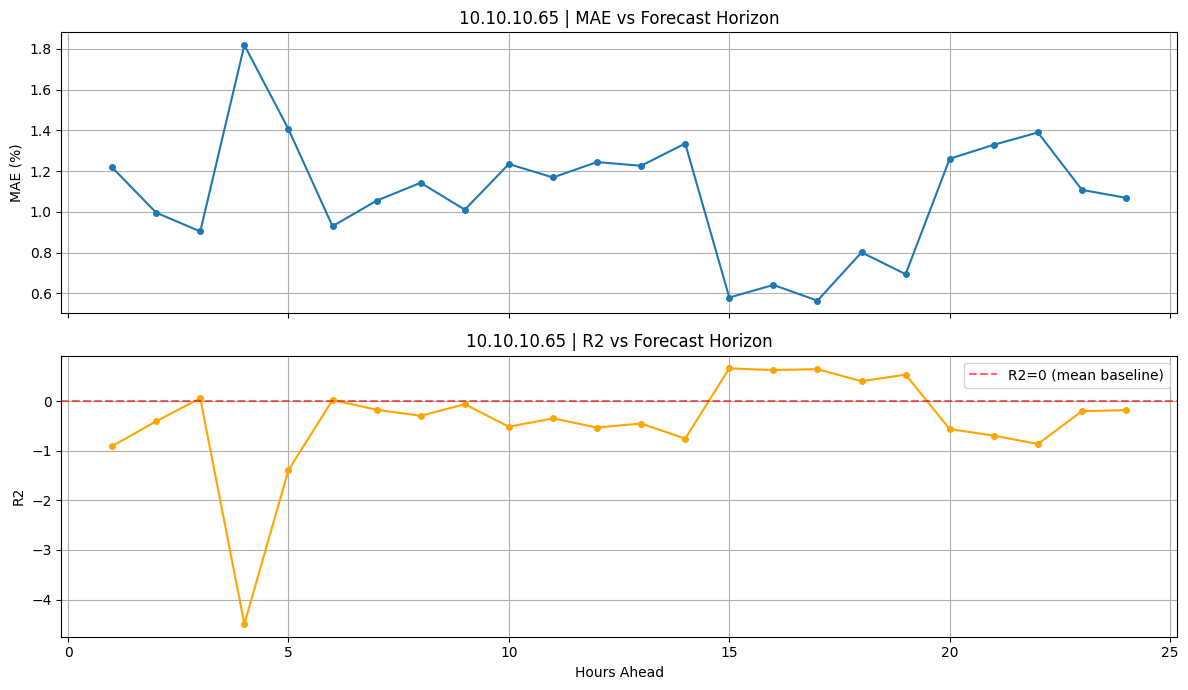

In [11]:
# 7a. MAE and R2 degradation over forecast horizon
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(range(1, FORECAST_HORIZON + 1), horizon_mae,
             marker='o', ms=4, linewidth=1.5)
axes[0].set_ylabel('MAE (%)')
axes[0].set_title(f'{SERVER_NAME} | MAE vs Forecast Horizon')
axes[0].grid(True)

axes[1].plot(range(1, FORECAST_HORIZON + 1), horizon_r2,
             marker='o', ms=4, linewidth=1.5, color='orange')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.6, label='R2=0 (mean baseline)')
axes[1].set_ylabel('R2')
axes[1].set_xlabel('Hours Ahead')
axes[1].set_title(f'{SERVER_NAME} | R2 vs Forecast Horizon')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

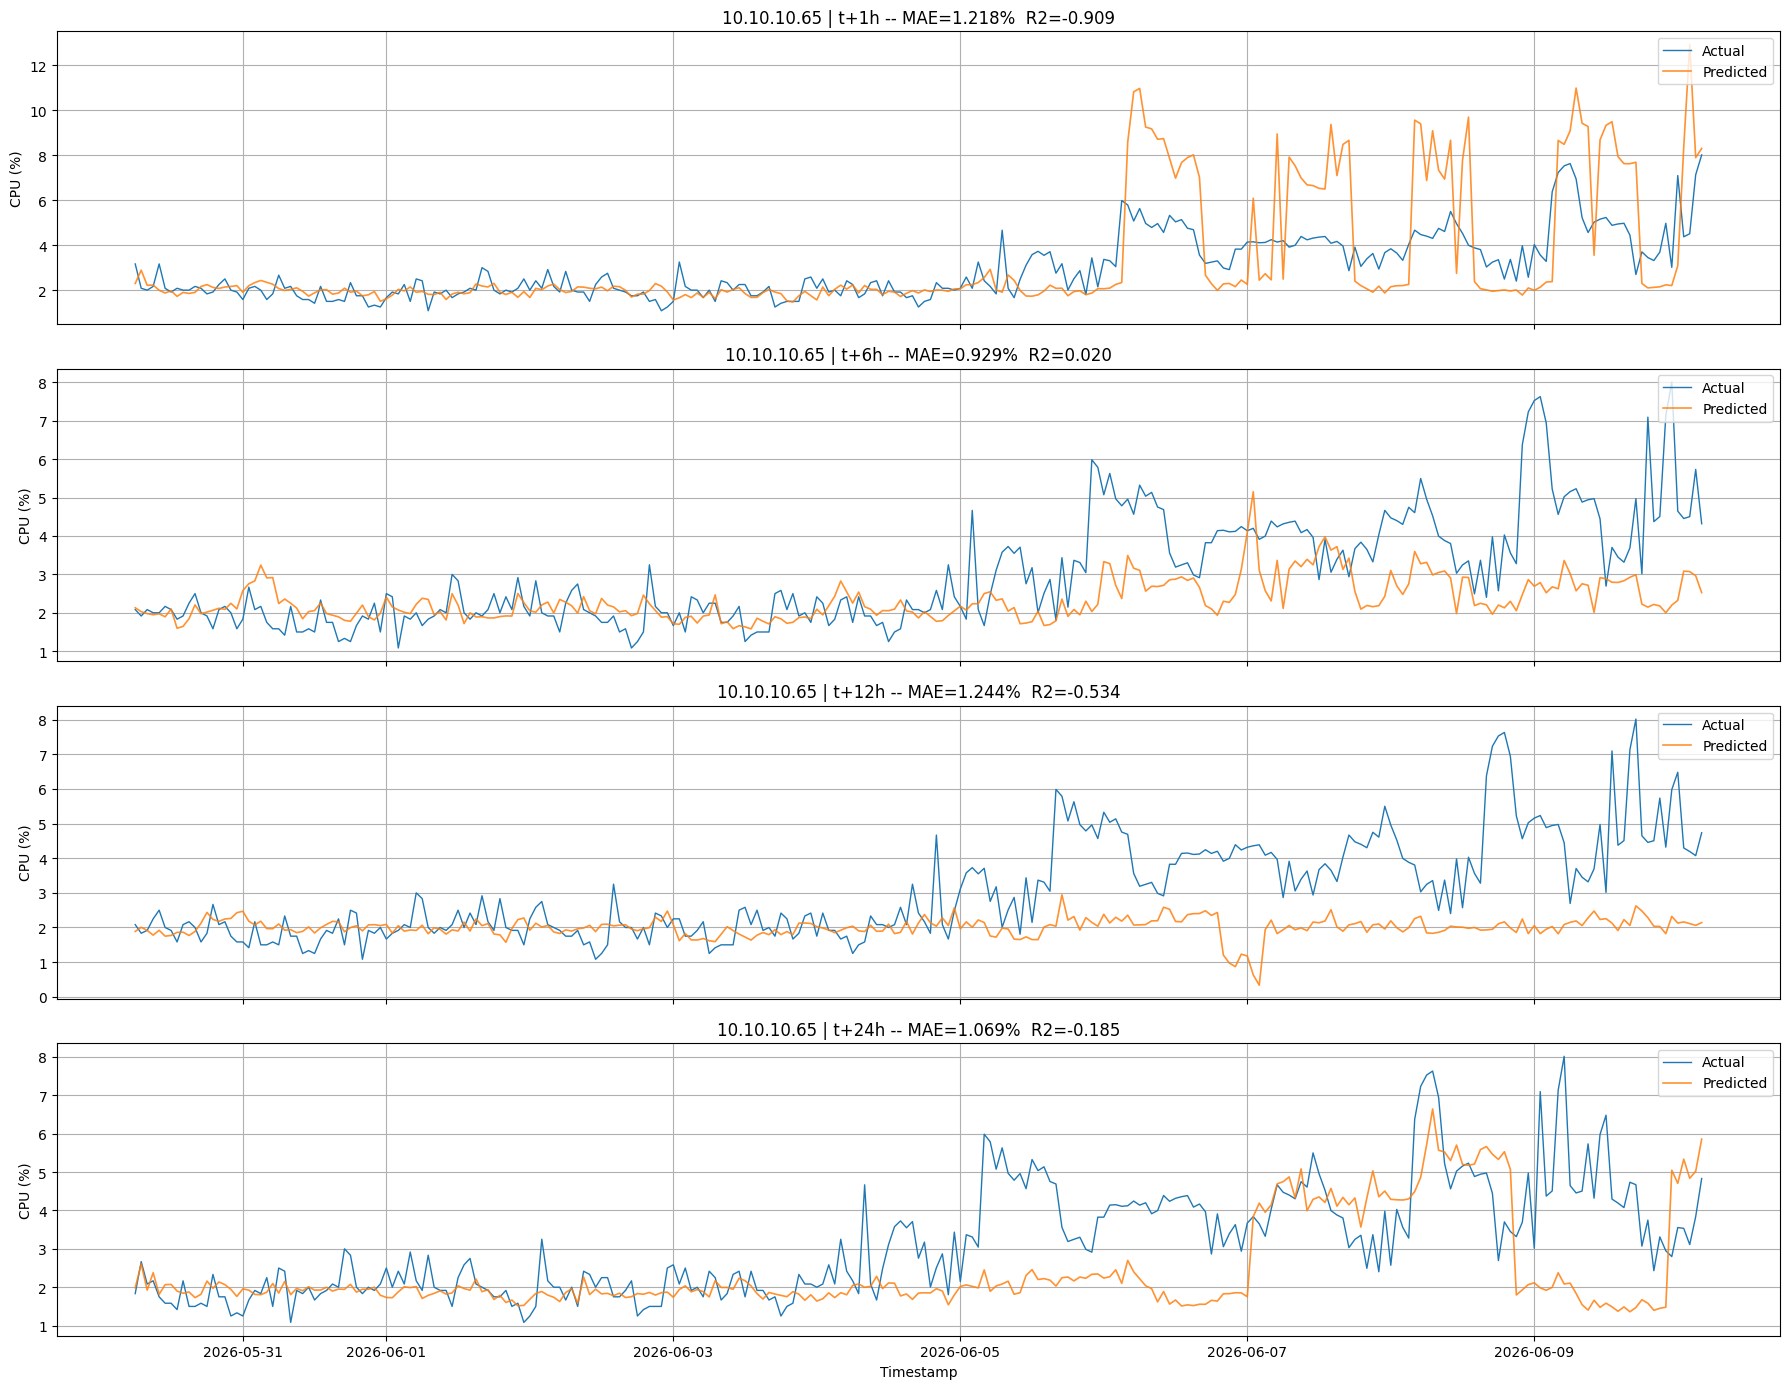

In [12]:
# 7b. Actual vs Predicted at t+1h, t+6h, t+12h, t+24h
check_steps = {'t+1h': 0, 't+6h': 5, 't+12h': 11, 't+24h': 23}

fig, axes = plt.subplots(len(check_steps), 1, figsize=(18, 14), sharex=True)

for ax, (label, idx) in zip(axes, check_steps.items()):
    ax.plot(test_df['ts'], Y_test.iloc[:, idx].values,
            label='Actual', linewidth=1)
    ax.plot(test_df['ts'], predictions[:, idx],
            label='Predicted', linewidth=1.2, alpha=0.85)
    ax.set_title(f'{SERVER_NAME} | {label} -- MAE={horizon_mae[idx]:.3f}%  R2={horizon_r2[idx]:.3f}')
    ax.set_ylabel('CPU (%)')
    ax.legend(loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()

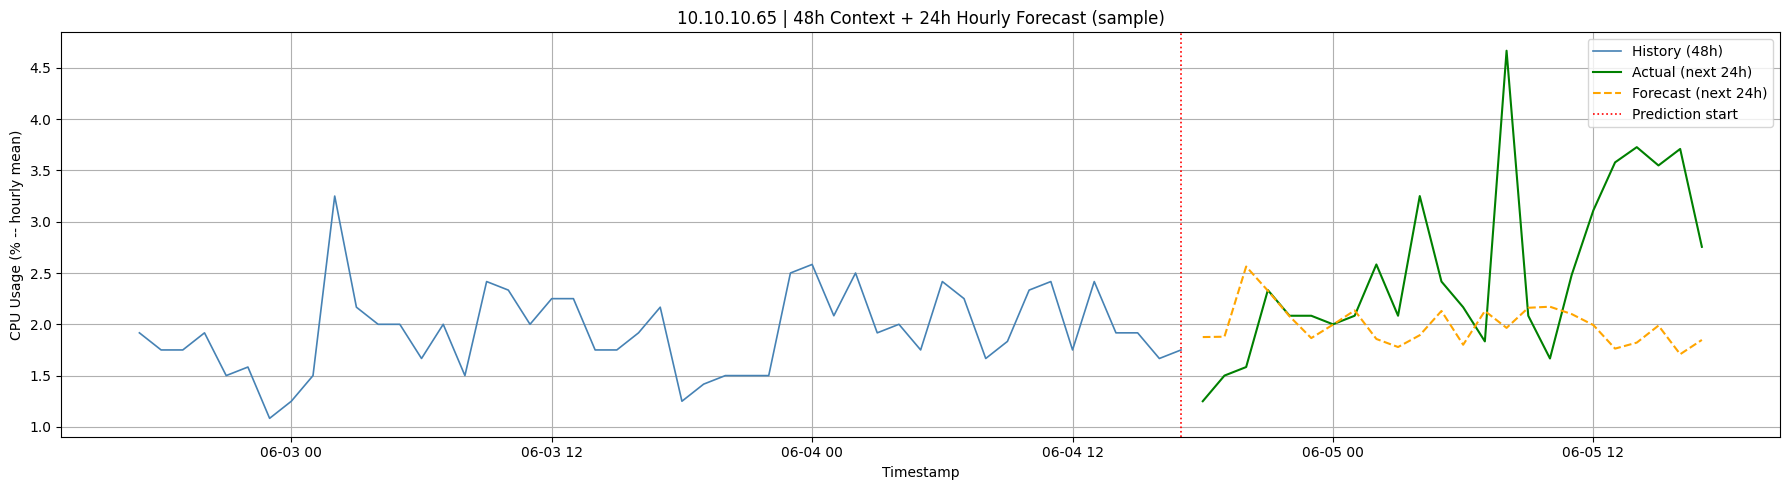

In [13]:
# 7c. Fan chart: 48h history + full 24h forecast for one sample window
SAMPLE_IDX = len(test_df) // 2

sample_pred   = predictions[SAMPLE_IDX]
sample_actual = Y_test.iloc[SAMPLE_IDX].values

forecast_ts = pd.date_range(
    start   = test_df['ts'].iloc[SAMPLE_IDX] + pd.Timedelta(hours=1),
    periods = FORECAST_HORIZON,
    freq    = '1h'
)

hist_end_loc   = test_df.index[SAMPLE_IDX]
hist_start_loc = max(0, hist_end_loc - 48)
history_ts     = df.loc[hist_start_loc:hist_end_loc, 'ts']
history_cpu    = df.loc[hist_start_loc:hist_end_loc, 'cpu_usage_pct']

plt.figure(figsize=(18, 5))
plt.plot(history_ts,  history_cpu,    color='steelblue', label='History (48h)',       linewidth=1.2)
plt.plot(forecast_ts, sample_actual,  color='green',     label='Actual (next 24h)',   linewidth=1.5)
plt.plot(forecast_ts, sample_pred,    color='orange',    label='Forecast (next 24h)', linewidth=1.5, linestyle='--')
plt.axvline(x=test_df['ts'].iloc[SAMPLE_IDX], color='red', linestyle=':', linewidth=1.2, label='Prediction start')
plt.title(f'{SERVER_NAME} | 48h Context + 24h Hourly Forecast (sample)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (% -- hourly mean)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

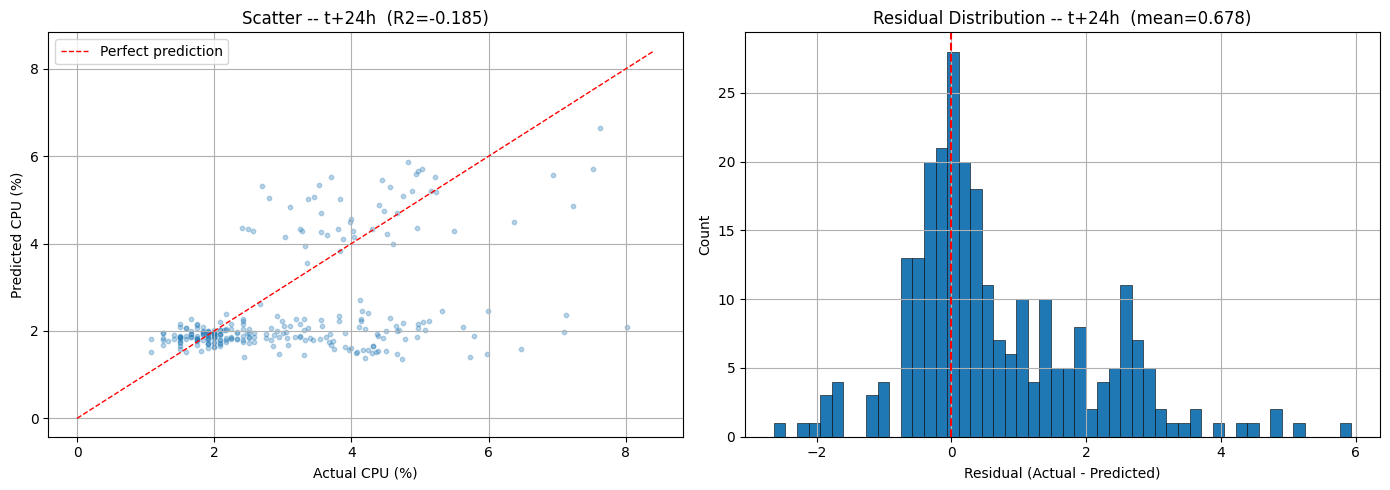

In [14]:
# 7d. Scatter + residual distribution at t+24h
actual_24h    = Y_test.iloc[:, -1].values
predicted_24h = predictions[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim = max(actual_24h.max(), predicted_24h.max()) * 1.05
axes[0].scatter(actual_24h, predicted_24h, alpha=0.3, s=10)
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual CPU (%)')
axes[0].set_ylabel('Predicted CPU (%)')
axes[0].set_title(f'Scatter -- t+24h  (R2={horizon_r2[-1]:.3f})')
axes[0].legend()
axes[0].grid(True)

residuals = actual_24h - predicted_24h
axes[1].hist(residuals, bins=50, edgecolor='black', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution -- t+24h  (mean={residuals.mean():.3f})')
axes[1].grid(True)

plt.tight_layout()
plt.show()

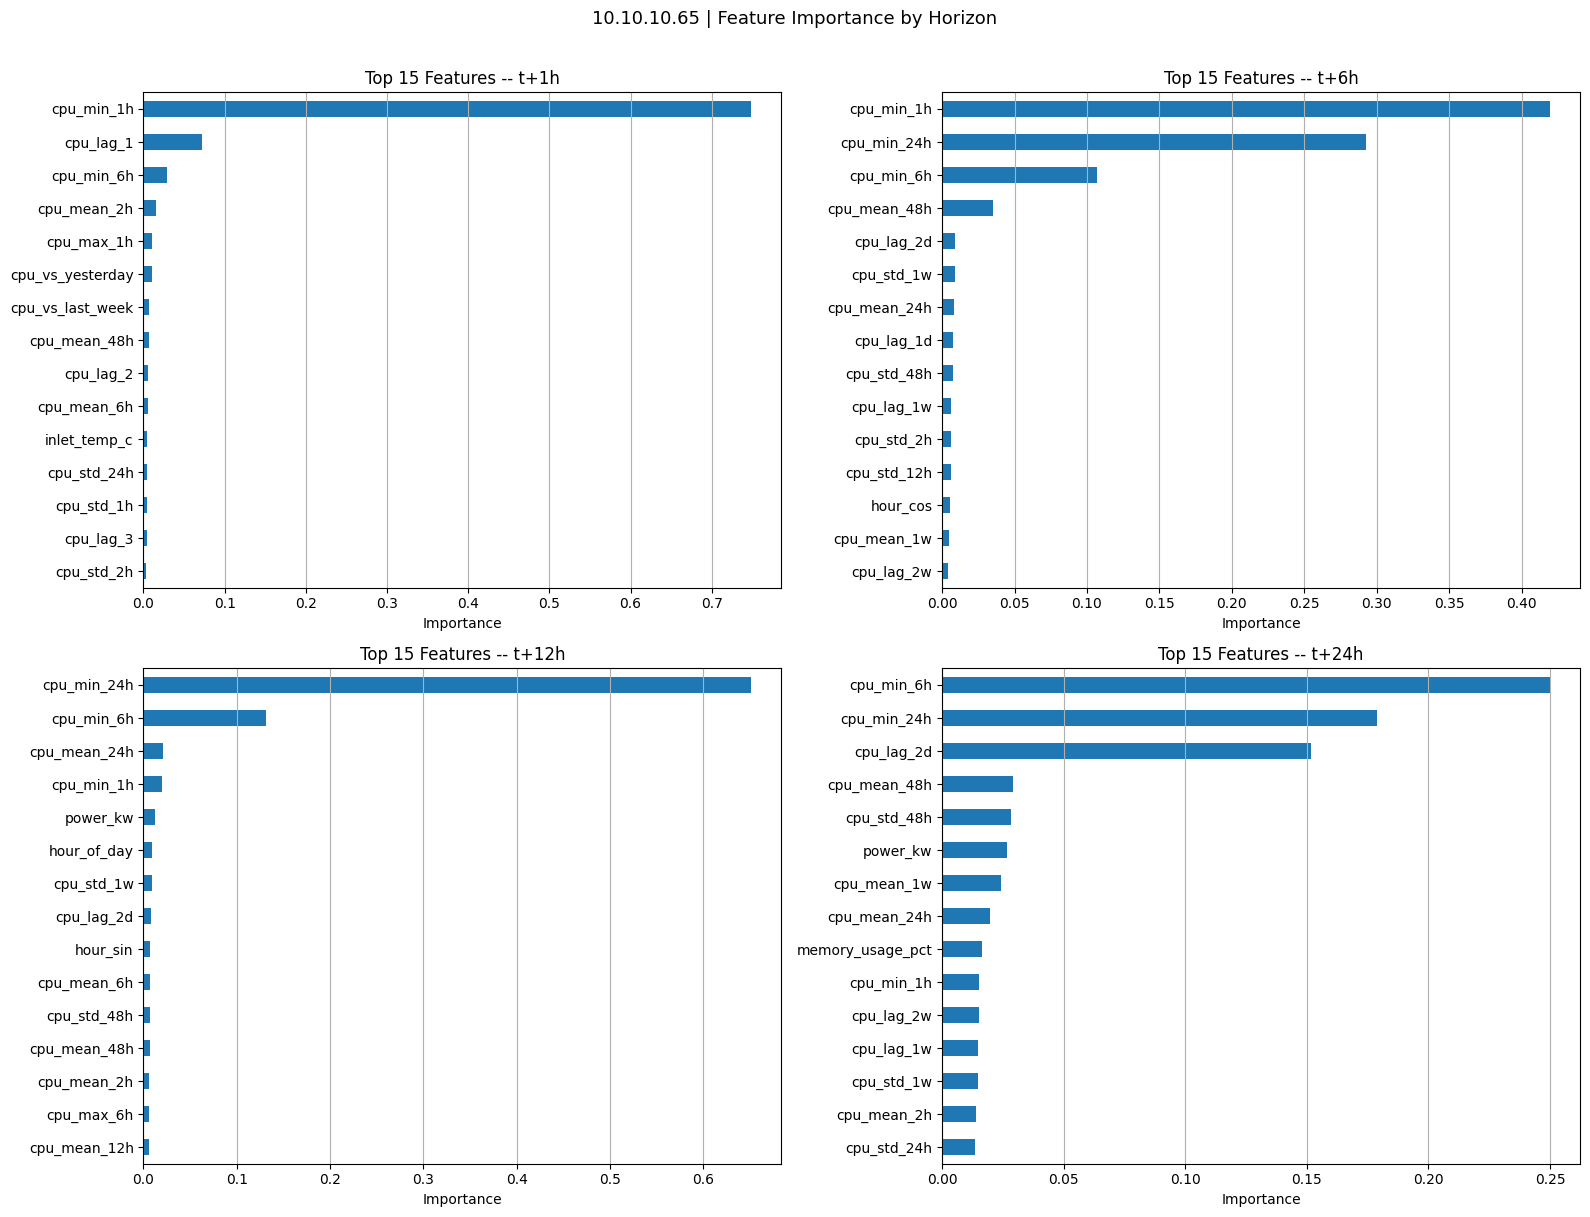

In [15]:
# 7e. Feature importance at t+1h, t+6h, t+12h, t+24h
sample_steps = {'t+1h': 0, 't+6h': 5, 't+12h': 11, 't+24h': 23}
TOP_N = 15

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (label, idx) in zip(axes, sample_steps.items()):
    imp = pd.Series(
        multi_model.estimators_[idx].feature_importances_,
        index=FEATURES
    ).nlargest(TOP_N)
    imp[::-1].plot(kind='barh', ax=ax)
    ax.set_title(f'Top {TOP_N} Features -- {label}')
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x')

plt.suptitle(f'{SERVER_NAME} | Feature Importance by Horizon', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Final Summary
print("=" * 55)
print("24-Hour Hourly Forecast -- Final Summary")
print("=" * 55)
print(f"Server             : {SERVER_NAME}")
print(f"Resampled to       : 1-hour intervals")
print(f"Total features     : {len(FEATURES)}")
print(f"Forecast horizon   : {FORECAST_HORIZON} hours")
print()
print(f"Target mean (test) : {target_mean:.4f}%")
print(f"Target std  (test) : {target_std:.4f}%")
print()
print(f"Overall MAE        : {overall_mae:.4f}%")
print(f"Overall RMSE       : {overall_rmse:.4f}%")
print(f"Overall R2         : {overall_r2:.4f}")
print(f"MAPE               : {mape:.2f}%")
print(f"MAE / target_mean  : {overall_mae/target_mean*100:.1f}%")
print()
best_h  = int(np.argmax(horizon_r2)) + 1
worst_h = int(np.argmin(horizon_r2)) + 1
print(f"Best R2 horizon    : t+{best_h}h  ({horizon_r2[best_h-1]:.4f})")
print(f"Worst R2 horizon   : t+{worst_h}h ({horizon_r2[worst_h-1]:.4f})")
print("=" * 55)

24-Hour Hourly Forecast -- Final Summary
Server             : 10.10.10.65
Resampled to       : 1-hour intervals
Total features     : 45
Forecast horizon   : 24 hours

Target mean (test) : 3.0503%
Target std  (test) : 1.4096%

Overall MAE        : 1.0883%
Overall RMSE       : 1.6692%
Overall R2         : -0.4022
MAPE               : 30.62%
MAE / target_mean  : 35.7%

Best R2 horizon    : t+15h  (0.6571)
Worst R2 horizon   : t+4h (-4.4926)
